In [1]:
import jax
from jax import flatten_util, vmap, grad 
import jax.numpy as jnp
import jax.random as jr

import matplotlib.pyplot as plt
from functools import partial
import optax
from helper_fns_general import sample_gaussian_mixture, normalize_samples, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization, setup_overdamped_SDE, solve_SDE, setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch
from plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, get_best_params
jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Generate samples from a Gaussian mixture

In [2]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 1000

# Define mixture weights (must sum to 1)
weights = jnp.array([.5, .5])

# Define means
means = jnp.array([
    [0.5, 0.0],   # mean of first Gaussian
    [-0.5, 0.0],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.01, 0.0],    # covariance of first Gaussian
        [0.0, 0.01]],
    [[0.01, 0.0],   # covariance of second Gaussian
        [0.0, 0.01]],
])

# Generate samples
samples = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)

### Plot samples and marginal distributions

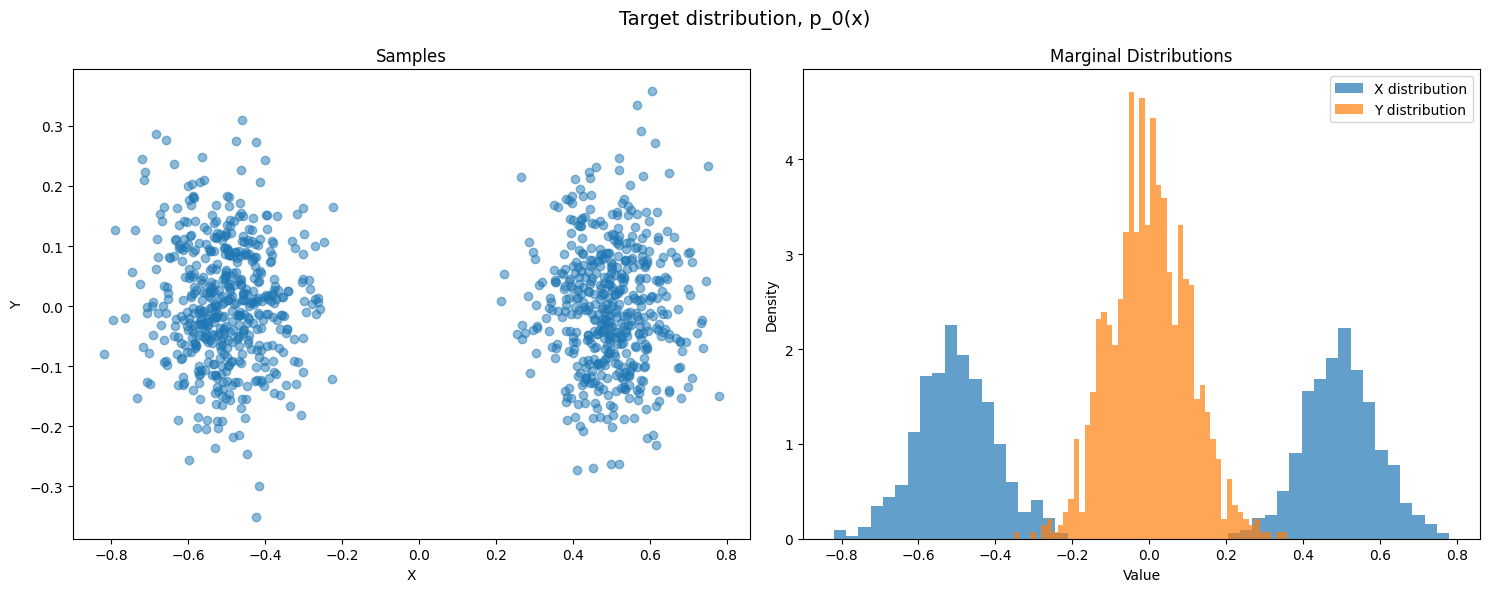

In [3]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')
ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Define energy function of duffing oscillator network

In [4]:
def energy_self_oscillator(x, k_lin, k_duff):
    return 1 / 2 * k_lin * x**2 + 1 / 4 * k_duff * x**4

def energy_self_network(x, k_lin, k_duff):
    return jnp.sum(vmap(energy_self_oscillator)(x, k_lin, k_duff))


def energy_coupling_pair(x, y, c_lin, c_optomech):
    return c_lin * x * (x - y) + c_lin * y * (y - x) + c_optomech * (x**2) * y

def energy_coupling_network(x, c_lin, c_optomech, connectivity):
    # get contribution to total energy from each pair of oscillators
    
    def _coupling_energy_pair(x, c_lin, c_optomech, pair):
        # get energy of one pair of oscillators
        i, j = pair
        return energy_coupling_pair(x[i], x[j], c_lin, c_optomech)

    # get energy of all pairs of oscillators
    return jnp.sum(
        vmap(_coupling_energy_pair, in_axes=(None, 0, 0, 0))(
            x, c_lin, c_optomech, connectivity
        )
    )

k_b = 1.0
T = .1
def _energy_duffing_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b=k_b, T=T):
    # returns energy of network of oscillators given input parameters
    return (
        energy_self_network(x, k_lin, k_duff) +
        energy_coupling_network(x, c_lin, c_optomech, connectivity)
    ) / (k_b * T)

### Define initial parameters

In [5]:
N_osc = 2

k_lin_0 = jnp.array([-1., -1.])
k_duff_0 = jnp.array([1., 1.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])
connectivity = jnp.array([[0, 1]])

args_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)

flattened_args_initial, unflatten = flatten_util.ravel_pytree(args_initial)

### Bringe energy into correct form

In [6]:
def energy_duffing_network(x, flattened_args, connectivity):
    k_lin, k_duffing, c_lin, c_optomech = unflatten(flattened_args)
    return _energy_duffing_network(x, k_lin, k_duffing, c_lin, c_optomech, connectivity)
energy_fn = lambda x, flattened_args: energy_duffing_network(x, flattened_args, connectivity)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


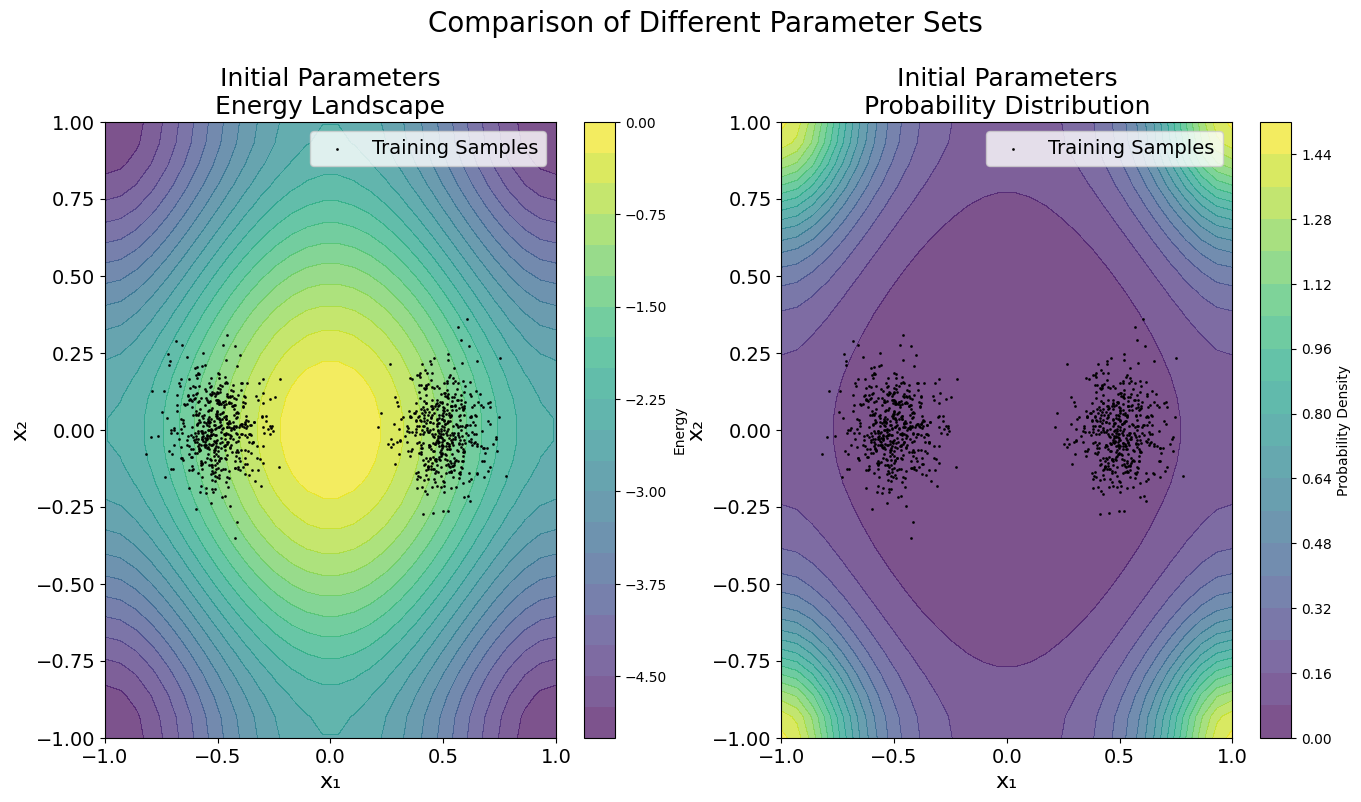

In [7]:
# Example usage:
param_list = [flattened_args_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Comparison of Different Parameter Sets" 
)

### Score Matching

In [8]:
learning_rate = 0.01
n_epochs = 4000
batch_size = 128
key, subkey = jr.split(key)
loss_fn_per_batch_SM = setup_score_matching_loss_per_batch(energy_fn)
params_history_SM, loss_history_SM = run_optimization(loss_fn_per_batch = loss_fn_per_batch_SM, 
                                                params_initial = flattened_args_initial, 
                                                samples=samples, 
                                                gradient_fn_per_batch = None, 
                                                key=subkey,
                                                batch_size=batch_size, 
                                                learning_rate=learning_rate, 
                                                n_epochs=n_epochs)

Epoch 0
params:
[-0.99 -0.99  1.01  1.01  0.01 -0.01]
Loss: 18.7225
---
Epoch 100
params:
[-0.58885264 -0.01716474  1.77056186  1.9595749   0.20227358 -0.05550953]
Loss: -12.3085
---
Epoch 200
params:
[-0.61227413  0.91910377  2.48148806  2.89724753  0.1319204  -0.02814727]
Loss: -23.4988
---
Epoch 300
params:
[-0.76924031  1.80880833  3.21178245  3.78367595  0.10928563 -0.07503881]
Loss: -33.3632
---
Epoch 400
params:
[-0.96289886  2.64703547  3.96267361  4.61090886  0.09253403 -0.07395595]
Loss: -43.0216
---
Epoch 500
params:
[-1.16748705  3.43631061  4.72210634  5.37054054  0.07509039 -0.01037479]
Loss: -51.1021
---
Epoch 600
params:
[-1.35655949  4.16621341  5.48187578  6.06765929  0.06711395 -0.03958957]
Loss: -59.2635
---
Epoch 700
params:
[-1.548714    4.84214021  6.22063152  6.70574162  0.06355111 -0.10528151]
Loss: -66.9630
---
Epoch 800
params:
[-1.75118777  5.46904697  6.94631965  7.28967378  0.04312345 -0.01134401]
Loss: -70.3705
---
Epoch 900
params:
[-1.90467507  6.042642

Best loss: -9.3815e+01
Found at epoch: 38340


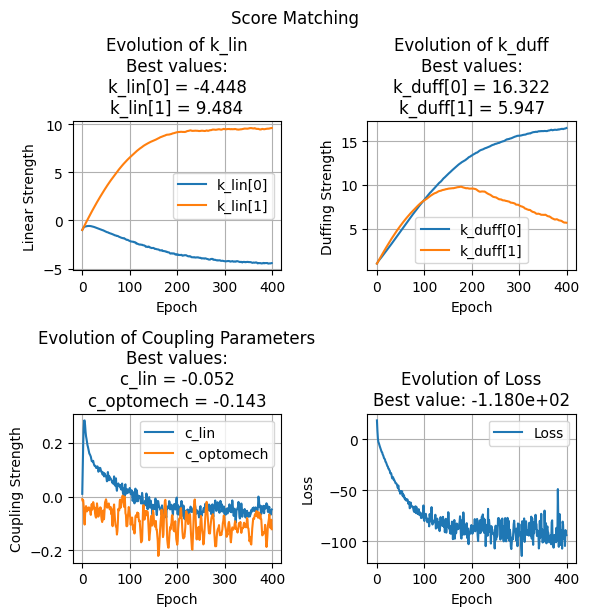

In [9]:
# For the first optimization
plot_parameter_evolution(
    params_history=params_history_SM,
    loss_history=loss_history_SM,
    unflatten=unflatten,
    N_osc=N_osc,
    slicing=10,
    title="Score Matching"
)
_, flattened_args_best_sm, _ = get_best_params(params_history_SM, loss_history_SM, maximize=False)
# k_lin_best_sm, k_duff_best_sm, c_lin_best_sm, c_optomech_best_sm = unflatten(best_params_sm)

# args_best_sm = (k_lin_best, k_duff_best, c_lin_best, c_optomech_best)
# flattened_args_best_sm, _ = flatten_util.ravel_pytree(args_best_sm)


### Contrastive Divergence 1

In [10]:
# Define optimization parameters
learning_rate = learning_rate
n_epochs = n_epochs
batch_size = batch_size
loss_fn_per_batch_SM = setup_score_matching_loss_per_batch(energy_fn)
key, subkey = jr.split(key)
cd1_grad = lambda params, batch: -CD1_gradient(energy_fn, 
                                               batch, 
                                               params, 
                                               dt=0.001, 
                                               D=1, 
                                               key=key, 
                                               num_noise_samples=100)

params_history_cd1, loss_history_cd1 = run_optimization(loss_fn_per_batch = loss_fn_per_batch_SM, 
                                                        params_initial = flattened_args_initial, 
                                                        samples=samples, 
                                                        gradient_fn_per_batch = cd1_grad, 
                                                        key=subkey,
                                                        batch_size=batch_size, 
                                                        learning_rate=learning_rate, 
                                                        n_epochs=n_epochs)

Epoch 0
params:
[-0.99 -0.99  1.01  1.01  0.01  0.01]
Loss: 18.9434
---
Epoch 100
params:
[-0.58647696 -0.01700389  1.76003149  1.96996562  0.20926782  0.21113414]
Loss: -11.6152
---
Epoch 200
params:
[-0.61378241  0.92089058  2.45082499  2.8721418   0.12711959  0.1939555 ]
Loss: -23.5869
---
Epoch 300
params:
[-0.76106417  1.81743737  3.16682979  3.73889846  0.13400512  0.22404817]
Loss: -33.1716
---
Epoch 400
params:
[-0.91764485  2.65847959  3.90194878  4.56873818  0.10660012  0.19408042]
Loss: -41.1792
---
Epoch 500
params:
[-1.11567753  3.443854    4.63001937  5.32874258  0.0810791   0.22835564]
Loss: -52.2455
---
Epoch 600
params:
[-1.29429126  4.17354536  5.34250854  6.03362879  0.0539647   0.16889892]
Loss: -56.2779
---
Epoch 700
params:
[-1.48499155  4.86412232  6.05544464  6.68419234  0.0823096   0.17126444]
Loss: -61.8263
---
Epoch 800
params:
[-1.66624018  5.49296728  6.77477874  7.25963915  0.03370533  0.2234934 ]
Loss: -70.4723
---
Epoch 900
params:
[-1.87766965  6.079610

Best loss: -1.1071e+02
Found at epoch: 39520


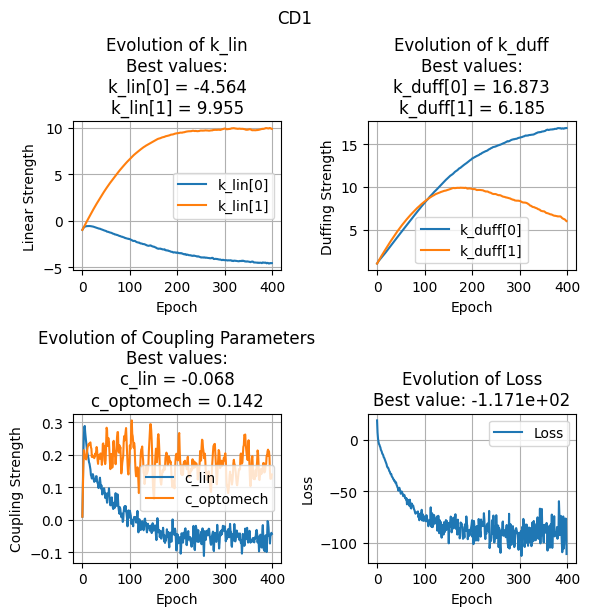

In [12]:
plot_parameter_evolution(
    params_history=params_history_cd1,
    loss_history=loss_history_cd1,
    unflatten=unflatten,
    N_osc=N_osc,
    slicing=10,
    title="CD1"
)

_, flattened_args_best_cd1, _ = get_best_params(params_history_SM, loss_history_SM, maximize=False)
# args_best_cd1 = (k_lin_best_cd1, k_duff_best_cd1, c_lin_best_cd1, c_optomech_best_cd1)
# flattened_args_best_cd1, _ = flatten_util.ravel_pytree(args_best_cd1)


### MLE

In [13]:
# Define optimization parameters
learning_rate = .5
n_epochs = 100
batch_size = samples.shape[0]//2
key, subkey = jr.split(key)
loss_fn_per_batch_MLE = setup_MLE_loss_per_batch(energy_fn)
gradient_fn_per_batch_MLE = setup_MLE_gradient_per_batch(energy_fn, 
                                                     N_osc, 
                                                     gamma=1.0, 
                                                     k_b=1.0, 
                                                     T=1.0, 
                                                     t0=0.0, 
                                                     t1=10.0, 
                                                     N_samples=1000, 
                                                     dt0=0.01, 
                                                     initial_state=jnp.array([0.,0.]))

params_history_mle, loss_history_mle = run_optimization(loss_fn_per_batch = loss_fn_per_batch_MLE, 
                                                        params_initial = flattened_args_initial, 
                                                        samples=samples,
                                                        gradient_fn_per_batch = gradient_fn_per_batch_MLE, 
                                                        key=key,
                                                        batch_size=batch_size, 
                                                        learning_rate=learning_rate, 
                                                        n_epochs=n_epochs, 
                                                        maximize=True)

/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

Epoch 0
params:
[-0.5 -0.5  1.5  1.5  0.5  0.5]
Loss: 573.5061
---


Best loss: 6.5095e+02
Found at epoch: 94


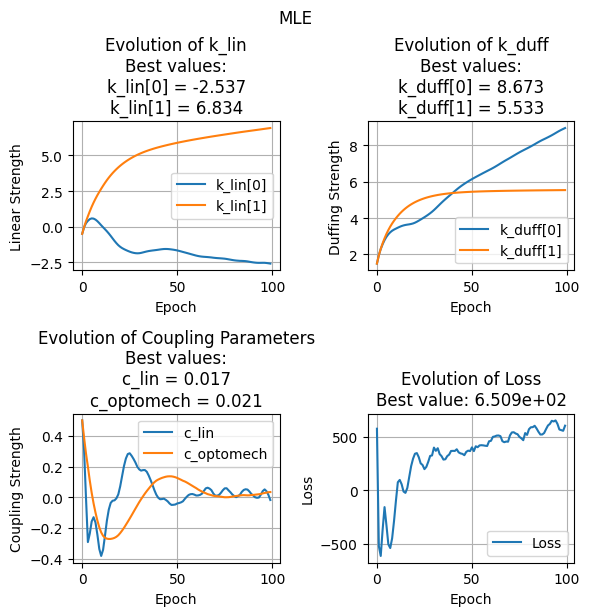

In [14]:
plot_parameter_evolution(
    params_history=params_history_mle,
    loss_history=loss_history_mle,
    unflatten=unflatten,
    N_osc=N_osc,
    slicing=1,
    title="MLE",
    maximize=True
)

_, flattened_args_best_mle, _ = get_best_params(params_history_SM, loss_history_SM, maximize=True)
# args_best_mle = (k_lin_best_mle, k_duff_best_mle, c_lin_best_mle, c_optomech_best_mle)
# flattened_args_best_mle, _ = flatten_util.ravel_pytree(args_best_mle)

### Compare solutions

Initial Parameters probability distribution total (should be ≈ 1): 1.000000
Score Matching Best probability distribution total (should be ≈ 1): 1.000000
CD-1 Best probability distribution total (should be ≈ 1): 1.000000
MLE Best probability distribution total (should be ≈ 1): 1.000000


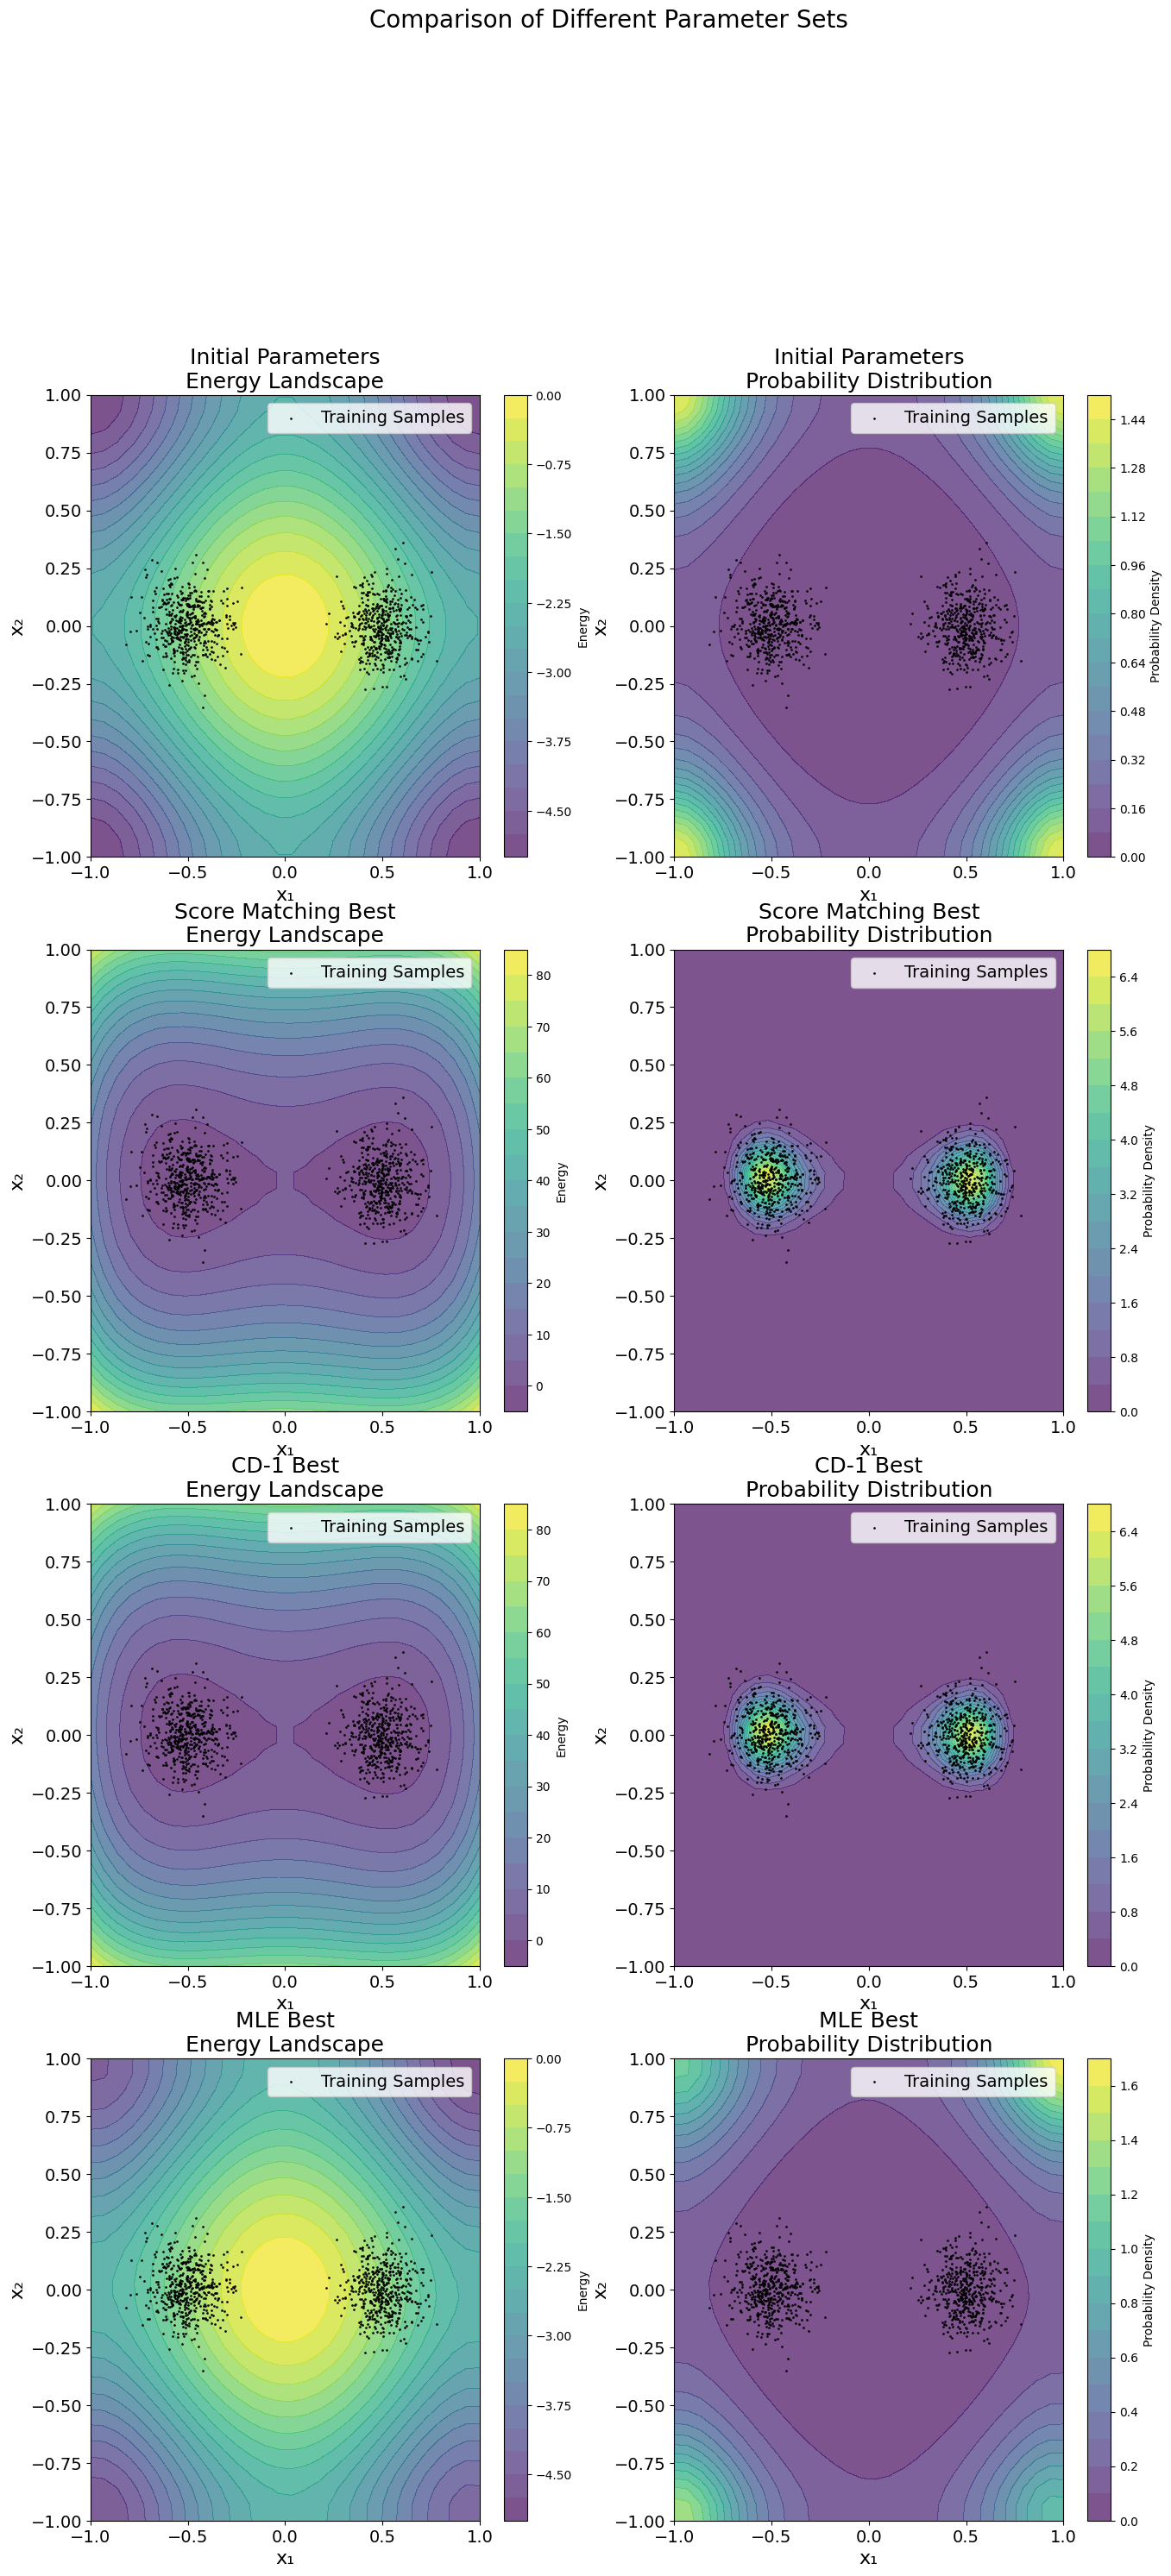

In [15]:
# Example usage:
param_list = [flattened_args_initial, flattened_args_best_sm, flattened_args_best_cd1, flattened_args_best_mle]
titles = ["Initial Parameters", "Score Matching Best", "CD-1 Best", "MLE Best"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples,
    x1_range=(-1, 1),    
    x2_range=(-1, 1),    
    n_points=30,        
    titles=titles,       
    figsize=None,    
    fontsize=16,
    sample_stride=1,
    suptitle="Comparison of Different Parameter Sets"  
)

### Run the SDE on one of the optimized energy landscape

In [16]:
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, flattened_args_best_sm, N_osc)
t0 = 0.0
t1 = 10 
ts = jnp.linspace(t0, t1, 10000)
dt0 = ts[1] - ts[0]
initial_state    = jnp.array([0.,0.])

solution = solve_SDE(drift_fn, diffusion_fn, initial_state, t0, t1, ts.shape[0], dt0)
sde_samples = solution.ys

Score Matching Best Energy  probability distribution total (should be ≈ 1): 1.000000


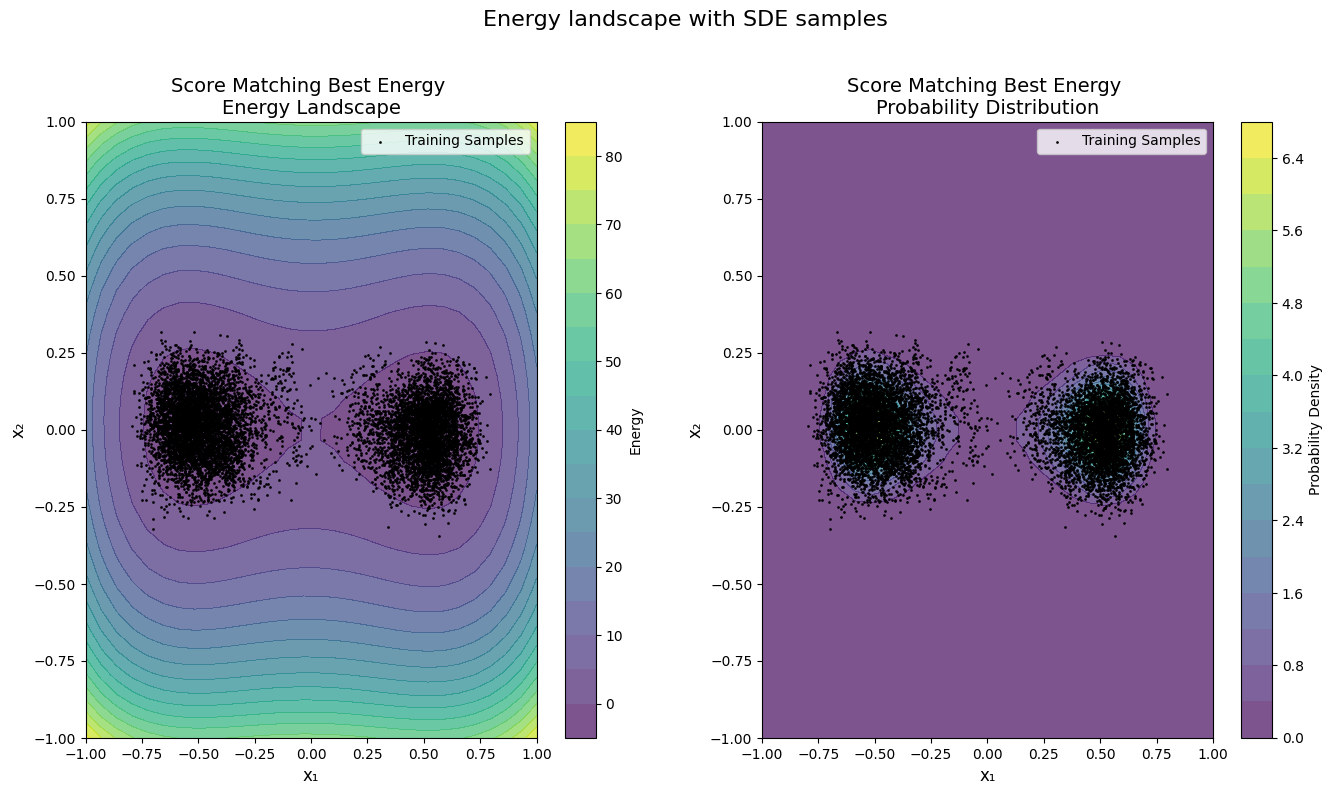

In [17]:
# Example usage:
param_list = [flattened_args_best_sm]
titles = ["Score Matching Best Energy "]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples,
    sample_stride=1,
    x1_range=(-1, 1),    # optional
    x2_range=(-1, 1),    # optional
    n_points=30,        # optional
    titles=titles,       # optional
    figsize=None,    # optional
    fontsize=12,         # optional
    suptitle="Energy landscape with SDE samples"  # optional
)